# MLP with Dimensionless Parameters — Case 2
Cylindrical heater → differential area element  
Features: R/H, b/H  |  Fixed constants: H=46 mm, d=21.2 mm, p=0.1 mm

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import time

size_text = 24
plt.rcParams.update({
    'axes.titlesize': size_text, 'axes.labelsize': size_text,
    'xtick.labelsize': size_text, 'ytick.labelsize': size_text,
    'legend.fontsize': size_text,
})
w, h_fig = 10, 6


## Dataset and dimensionless features

In [2]:
# Fixed geometric constants for this dataset
H   = 46.0   # heater height   (mm)  — reference length
d_c = 21.2   # distance        (mm)  — fixed
p_c =  0.1   # element size    (mm)  — fixed

df = pd.read_csv("../data/Case_2.csv")

df['R_H'] = df['R'] / H   # heater radius / heater height
df['b_H'] = df['b'] / H   # axial position / heater height

feat_names = ['R_H', 'b_H']
X = df[feat_names].values
y = df['Fij'].values.reshape(-1, 1)

print(f"Dataset shape: {df.shape}")
print(f"\nDimensionless feature ranges:")
for f in feat_names:
    print(f"  {f:>5s}: [{df[f].min():.4f}, {df[f].max():.4f}]  ({df[f].nunique()} unique)")
print(f"\nFixed constants (not used as features — zero variance in this dataset):")
print(f"  d/H = {d_c/H:.4f}   p/H = {p_c/H:.6f}")
print(f"\nNote: including d/H and p/H as model inputs would be correct for a")
print(f"dataset where d or p are also varied (future extension).")


Dataset shape: (40000, 5)

Dimensionless feature ranges:
    R_H: [0.1087, 0.9783]  (200 unique)
    b_H: [0.0000, 0.9783]  (200 unique)

Fixed constants (not used as features — zero variance in this dataset):
  d/H = 0.4609   p/H = 0.002174

Note: including d/H and p/H as model inputs would be correct for a
dataset where d or p are also varied (future extension).


## Train – Test split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]}   Test: {X_test.shape[0]}")


Train: 32000   Test: 8000


## Scaling and tensors

In [4]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train).ravel()
y_test_scaled  = scaler_y.transform(y_test).ravel()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train_scaled.reshape(-1,1), dtype=torch.float32).to(device)
X_test_tensor  = torch.tensor(X_test_scaled,  dtype=torch.float32).to(device)
y_test_tensor  = torch.tensor(y_test_scaled.reshape(-1,1),  dtype=torch.float32).to(device)

train_dl = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=256, shuffle=True)


Using device: cuda


## MLP architecture  (2 dimensionless inputs)

In [5]:
class MLP(nn.Module):
    def __init__(self, in_dim: int = 2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64), nn.GELU(),
            nn.Linear(64, 64),     nn.GELU(),
            nn.Linear(64, 32),     nn.GELU(),
            nn.Linear(32, 1)
        )
    def forward(self, x): return self.net(x)

model = MLP().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {n_params:,}  ({n_params*4/1024:.1f} KB)")


Parameters: 6,465  (25.3 KB)


## Training

In [6]:
loss_fn   = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

EPOCHS = 500
train_losses, val_losses = [], []

t0 = time.perf_counter()
for epoch in range(1, EPOCHS + 1):
    model.train()
    for xb, yb in train_dl:
        optimizer.zero_grad()
        loss_fn(model(xb), yb).backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        tl = loss_fn(model(X_train_tensor), y_train_tensor).item()
        vl = loss_fn(model(X_test_tensor),  y_test_tensor).item()
    train_losses.append(tl); val_losses.append(vl)

    if epoch % 100 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | Train MSE: {tl:.4e} | Test MSE: {vl:.4e}")

T_train = time.perf_counter() - t0

model.eval()
if torch.cuda.is_available(): torch.cuda.synchronize()
t2 = time.perf_counter()
_ = model(X_test_tensor).detach()
if torch.cuda.is_available(): torch.cuda.synchronize()
T_pred = (time.perf_counter() - t2) / X_test_tensor.shape[0]

print(f"\nTraining time : {T_train:.2f} s")
print(f"Inference time: {T_pred*1e6:.4f} µs/sample")


Epoch   1 | Train MSE: 5.0798e-02 | Test MSE: 4.9934e-02
Epoch 100 | Train MSE: 2.9022e-04 | Test MSE: 1.6116e-04
Epoch 200 | Train MSE: 2.8775e-04 | Test MSE: 2.2220e-04
Epoch 300 | Train MSE: 6.1729e-04 | Test MSE: 5.6015e-04
Epoch 400 | Train MSE: 1.4803e-04 | Test MSE: 9.9729e-05
Epoch 500 | Train MSE: 7.8062e-05 | Test MSE: 5.5304e-05

Training time : 71.97 s
Inference time: 0.0238 µs/sample


## Learning curves

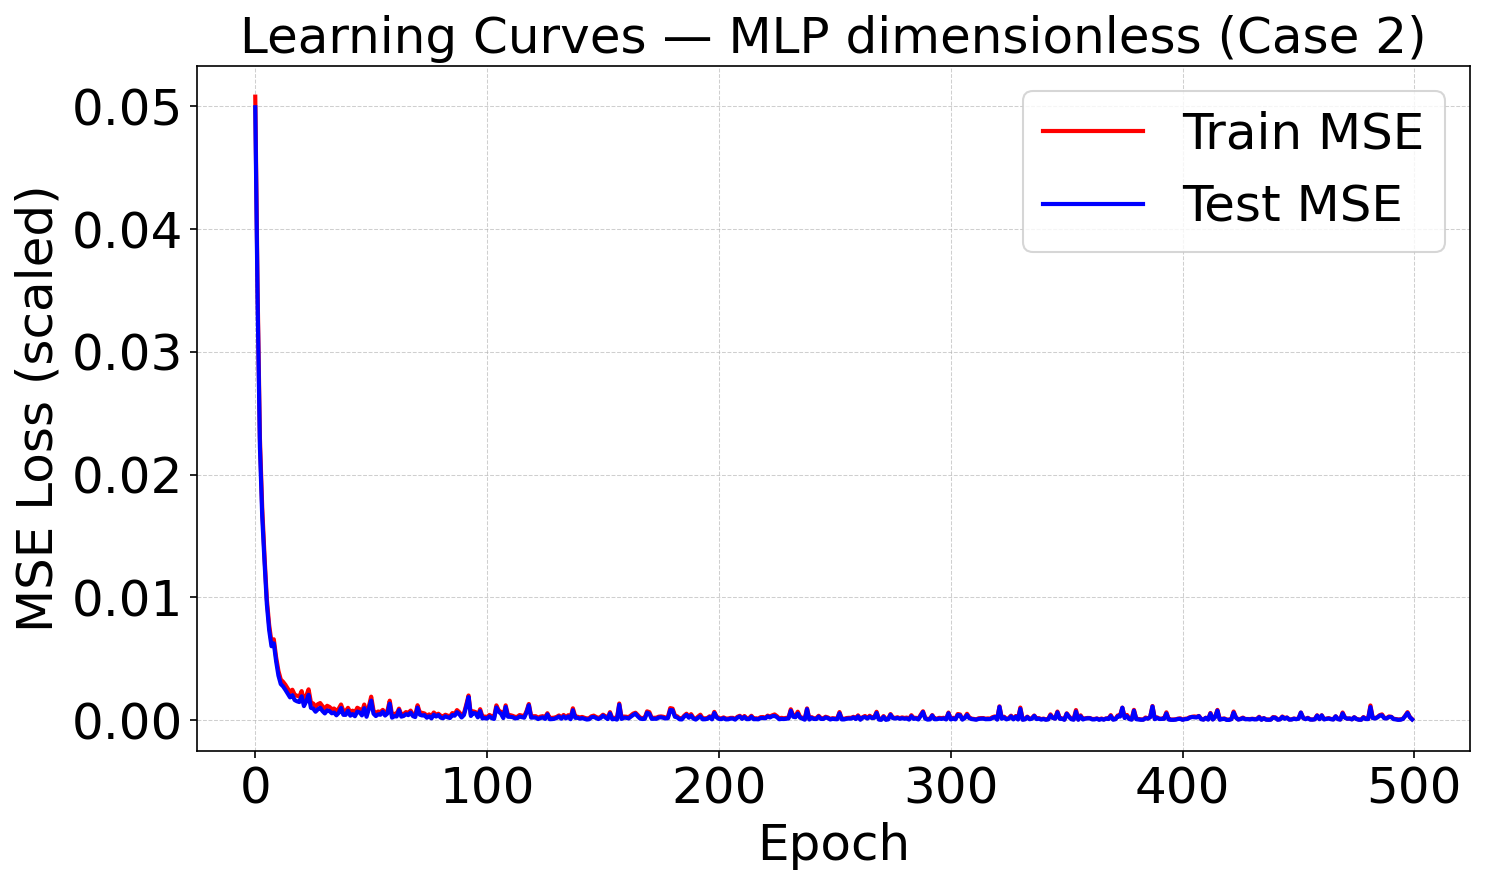

In [7]:
fig, ax = plt.subplots(figsize=(w, h_fig), dpi=150)
ax.plot(train_losses, 'r-', linewidth=2, label='Train MSE')
ax.plot(val_losses,   'b-', linewidth=2, label='Test MSE')
ax.set_title("Learning Curves — MLP dimensionless (Case 2)")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss (scaled)")
ax.legend(); ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
plt.tight_layout()
plt.savefig("learning_curve_mlp_dimless_C2.pdf", dpi=400, bbox_inches='tight')
plt.show()


## Metrics

In [8]:
model.eval()
with torch.no_grad():
    ytr_pred_s = model(X_train_tensor).cpu().numpy()
    yte_pred_s = model(X_test_tensor).cpu().numpy()

y_train_pred = scaler_y.inverse_transform(ytr_pred_s)
y_test_pred  = scaler_y.inverse_transform(yte_pred_s)
y_train_true = scaler_y.inverse_transform(y_train_tensor.cpu().numpy())
y_test_true  = scaler_y.inverse_transform(y_test_tensor.cpu().numpy())

def metrics(yt, yp, label):
    mse  = mean_squared_error(yt, yp)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(yt, yp)
    r2   = r2_score(yt, yp)
    mape = np.mean(np.abs((yt - yp) / yt)) * 100
    print(f"{label}:  MSE={mse:.4e}  RMSE={rmse:.4e}  MAE={mae:.4e}  R²={r2:.6f}  MAPE={mape:.4f}%")
    return mse, rmse, mae, r2, mape

metrics(y_train_true, y_train_pred, "Train")
_, _, _, _, mape_test = metrics(y_test_true, y_test_pred, "Test ")


Train:  MSE=3.0825e-06  RMSE=1.7557e-03  MAE=8.1708e-04  R²=0.999922  MAPE=0.1510%
Test :  MSE=2.1838e-06  RMSE=1.4778e-03  MAE=8.0869e-04  R²=0.999945  MAPE=0.1503%


## Prediction error bands

In [9]:
rel_err = np.abs((y_test_true - y_test_pred) / y_test_true)
print("Percentage of test predictions within tolerance:")
for tol in [0.01, 0.02, 0.05, 0.10]:
    print(f"  < {tol*100:.0f}%  →  {np.mean(rel_err < tol)*100:.2f}%")


Percentage of test predictions within tolerance:
  < 1%  →  99.06%
  < 2%  →  99.78%
  < 5%  →  99.98%
  < 10%  →  100.00%


## Comparison: dimensional  vs  dimensionless

In [10]:
# Original dimensional model results (from Neural_network_case_2.ipynb)
mape_dim = 0.9367
r2_dim   = 0.996575
rmse_dim = 1.170e-2

print(f"{'Metric':<20} {'Dimensional':>14} {'Dimensionless':>14}")
print("-" * 50)
print(f"{'MAPE test (%)':<20} {mape_dim:>14.4f} {mape_test:>14.4f}")
print(f"{'R² test':<20} {r2_dim:>14.6f} {r2_score(y_test_true, y_test_pred):>14.6f}")
print(f"{'RMSE test':<20} {rmse_dim:>14.4e} {np.sqrt(mean_squared_error(y_test_true, y_test_pred)):>14.4e}")


Metric                  Dimensional  Dimensionless
--------------------------------------------------
MAPE test (%)                0.9367         0.1503
R² test                    0.996575       0.999945
RMSE test                1.1700e-02     1.4778e-03


## Predicted vs actual  (test set)

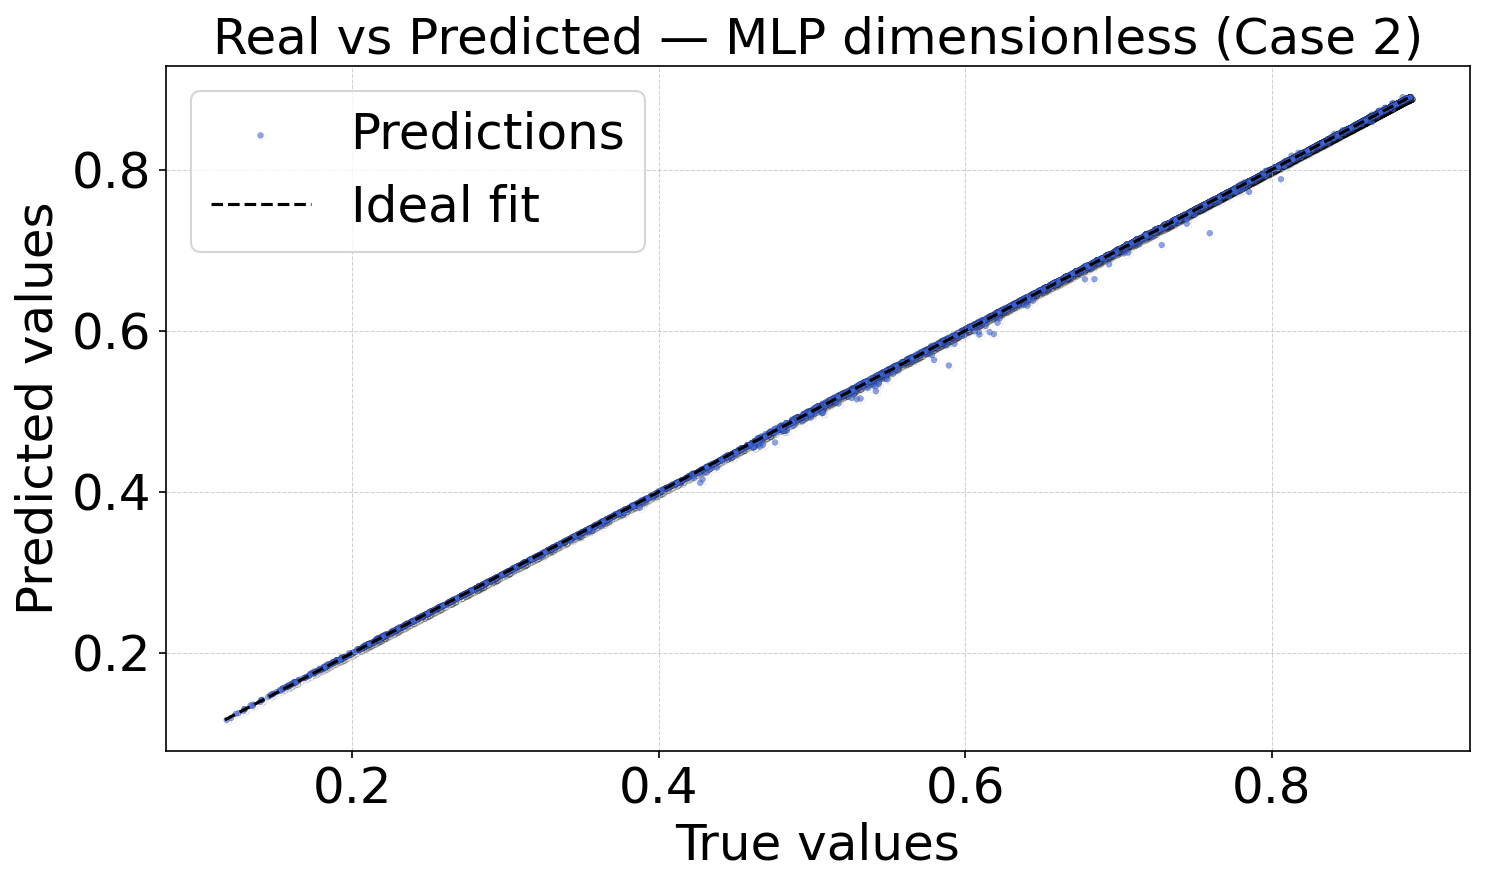

In [11]:
fig, ax = plt.subplots(figsize=(w, h_fig), dpi=150)
shadow = [pe.SimpleLineShadow(offset=(1,-1), alpha=0.25), pe.Normal()]
sc = ax.scatter(y_test_true, y_test_pred, s=8, alpha=0.6,
                color='royalblue', edgecolor='black', linewidth=0.1,
                label='Predictions')
sc.set_path_effects(shadow)
mn = float(min(y_test_true.min(), y_test_pred.min()))
mx = float(max(y_test_true.max(), y_test_pred.max()))
ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1.5, label='Ideal fit')
ax.set_title("Real vs Predicted — MLP dimensionless (Case 2)")
ax.set_xlabel("True values"); ax.set_ylabel("Predicted values")
ax.legend(); ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
plt.tight_layout()
plt.savefig("real_vs_pred_mlp_dimless_C2.pdf", dpi=400, bbox_inches='tight')
plt.show()


## Prediction surface  (R/H  vs  b/H)

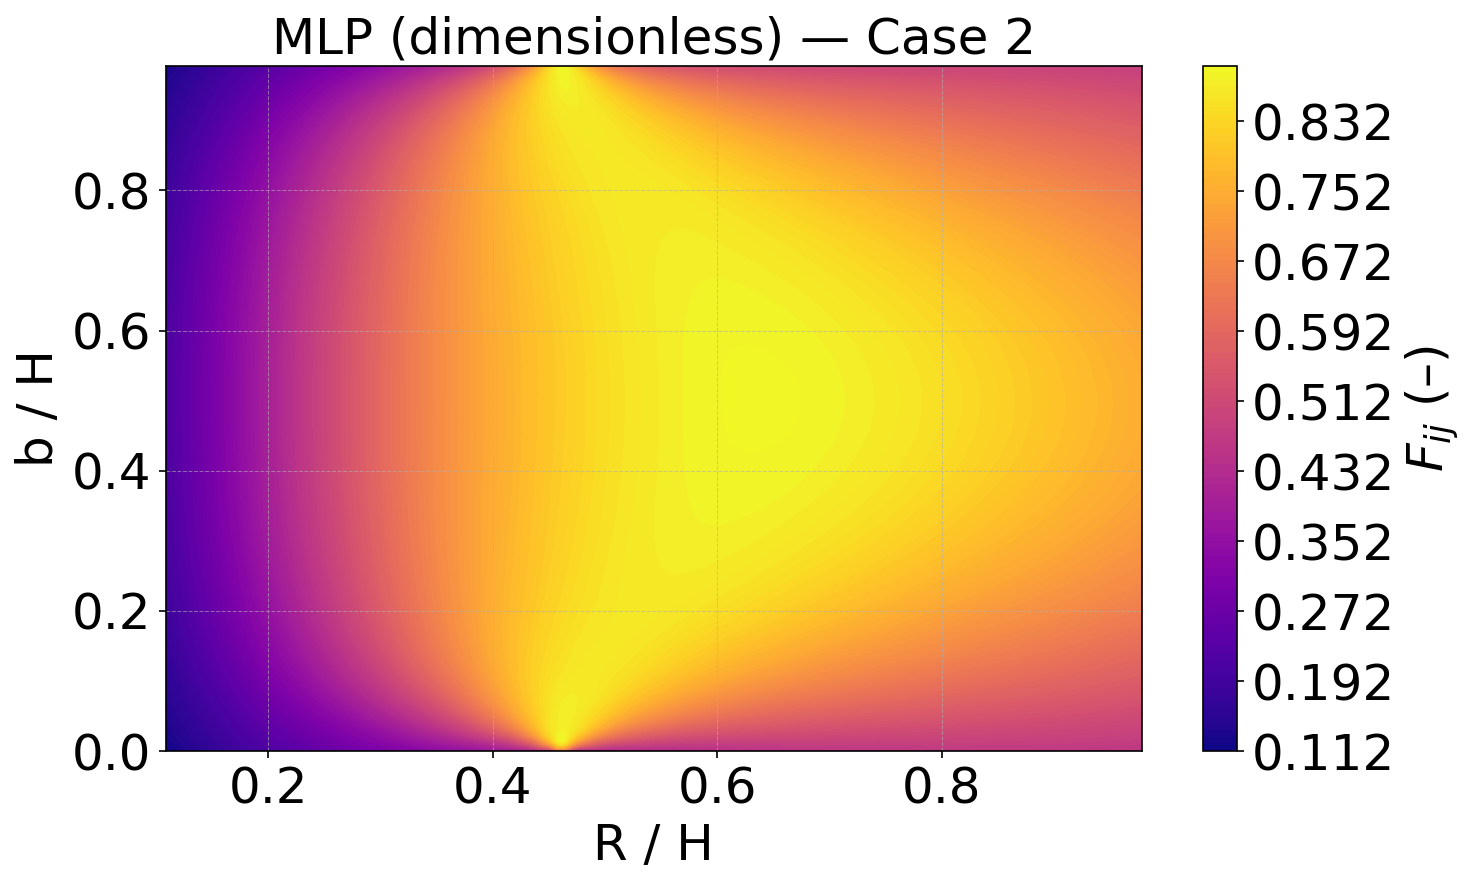

In [12]:
rh_vals = np.linspace(df['R_H'].min(), df['R_H'].max(), 200)
bh_vals = np.linspace(df['b_H'].min(), df['b_H'].max(), 200)
RH, BH  = np.meshgrid(rh_vals, bh_vals)

X_grid   = np.stack([RH.ravel(), BH.ravel()], axis=1)
X_grid_s = scaler_X.transform(X_grid)

model.eval()
with torch.no_grad():
    F_s = model(torch.tensor(X_grid_s, dtype=torch.float32).to(device)).cpu().numpy()

F_grid = scaler_y.inverse_transform(F_s).reshape(RH.shape)

fig, ax = plt.subplots(figsize=(w, h_fig), dpi=150)
cf = ax.contourf(RH, BH, F_grid, levels=100, cmap='plasma')
cbar = fig.colorbar(cf)
cbar.set_label(r'$F_{ij}$ (–)')
ax.set_title("MLP (dimensionless) — Case 2")
ax.set_xlabel("R / H"); ax.set_ylabel("b / H")
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
plt.tight_layout()
plt.savefig("surface_mlp_dimless_C2.pdf", dpi=400, bbox_inches='tight')
plt.show()


# SHAP Analysis

## Setup and compute SHAP values

In [13]:
import shap

model.to(device); model.eval()
torch.manual_seed(42)
bg  = X_train_tensor[torch.randperm(X_train_tensor.shape[0])[:200]]
expl = shap.GradientExplainer(model, bg)

n_ex = min(1000, X_test_tensor.shape[0])
sv   = expl.shap_values(X_test_tensor[:n_ex])
sv   = sv[0] if isinstance(sv, list) else sv
if sv.ndim == 3: sv = sv.squeeze(-1)

feat_shap   = ['R/H', 'b/H']
X_ex_orig   = X_test[:n_ex]

print(f"SHAP shape: {sv.shape}")
print("Mean |SHAP| per feature:")
for i, nm in enumerate(feat_shap):
    print(f"  {nm}: {np.abs(sv[:,i]).mean():.6f}")


/home/mijaillittin/miniconda3/envs/ml-gpu/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP shape: (1000, 2)
Mean |SHAP| per feature:
  R/H: 0.737794
  b/H: 0.306659


## Bar plot

/tmp/ipykernel_3746059/1155592461.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_ex_orig, feature_names=feat_shap, plot_type='bar', show=False)


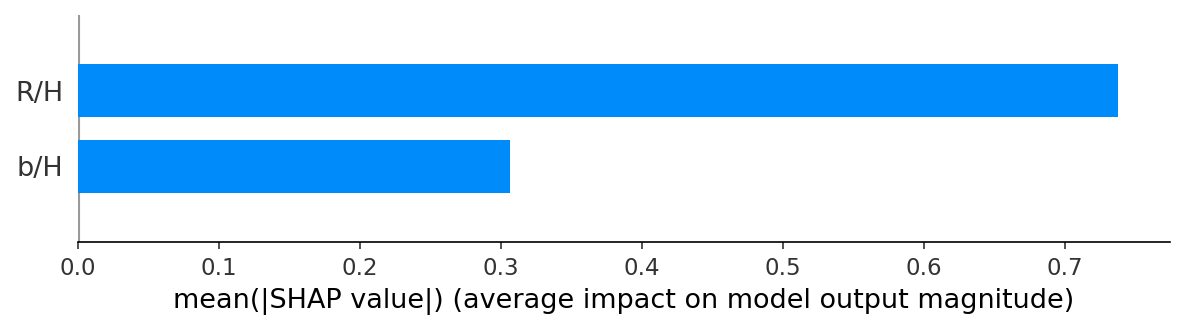

In [14]:
plt.figure(figsize=(7, 4), dpi=150)
shap.summary_plot(sv, X_ex_orig, feature_names=feat_shap, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig("shap_bar_dimless_C2.pdf", dpi=400, bbox_inches='tight')
plt.show()


## Beeswarm plot

/tmp/ipykernel_3746059/1908693446.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_ex_orig, feature_names=feat_shap, show=False)


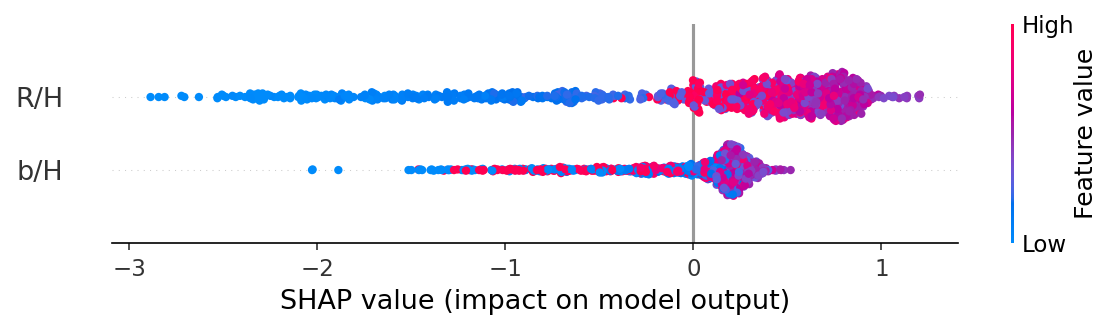

In [15]:
plt.figure(figsize=(7, 5), dpi=150)
shap.summary_plot(sv, X_ex_orig, feature_names=feat_shap, show=False)
plt.tight_layout()
plt.savefig("shap_beeswarm_dimless_C2.pdf", dpi=400, bbox_inches='tight')
plt.show()


## Dependence plots

<Figure size 1200x750 with 0 Axes>

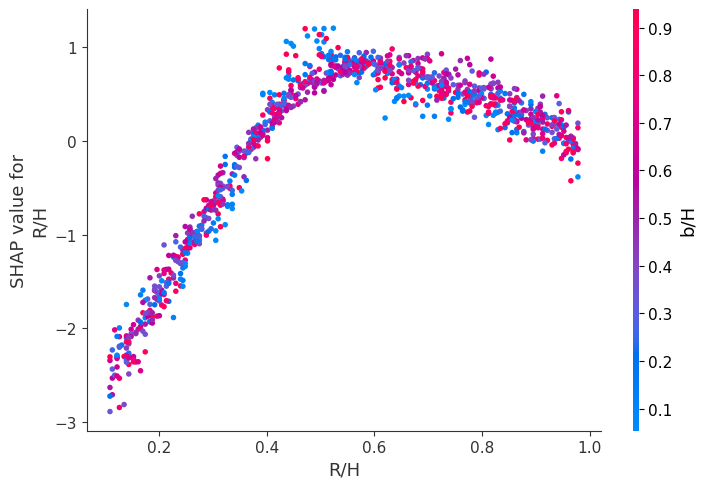

<Figure size 1200x750 with 0 Axes>

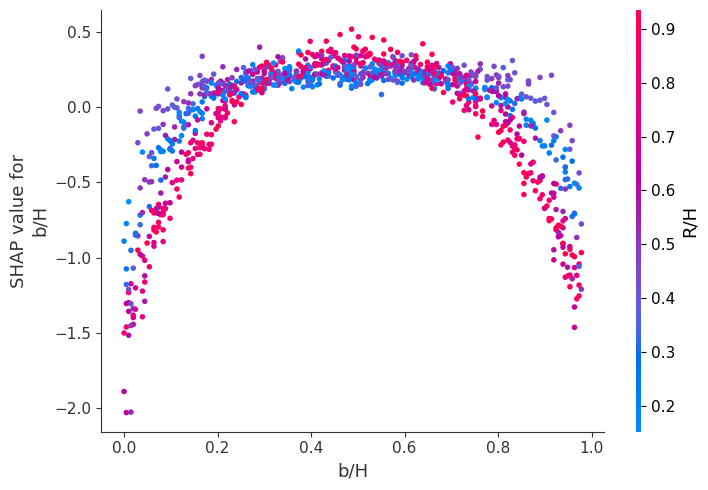

In [16]:
for i, nm in enumerate(feat_shap):
    plt.figure(figsize=(8, 5), dpi=150)
    shap.dependence_plot(i, sv, X_ex_orig, feature_names=feat_shap, show=False)
    plt.tight_layout()
    fname = nm.replace('/', '_')
    plt.savefig(f"shap_dependence_{fname}_dimless_C2.pdf", dpi=400, bbox_inches='tight')
    plt.show()
